In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/Colab\ Notebooks

'Copy of FLASK.ipynb'	    notebooks_02_modeling.ipynb		   scaler.pkl
 dynamic_transactions.csv   optimal_threshold.pkl		   sma.ipynb
 feature_list.pkl	    paysim1.zip				   template
 final_fraud_model.pkl	    PS_20174392719_1491204439457_log.csv
'notebooks 01_eda.ipynb'   'role_2(updated).ipynb'


In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [4]:
# ✅ Loading the continuous PaySim dataset (live URL, 24/7 stream)
import time

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv')

print(f"✅ Loaded {len(df)} transactions from continuous PaySim stream")
print(f"Fraud: {df['Fraudulent'].sum()} | Legit: {(df['Fraudulent']==0).sum()}")

# Simulate continuous data arriving in batches
def stream_batch(dataframe, batch_size=1000, batch_num=0):
    start = batch_num * batch_size
    batch = dataframe.iloc[start : start + batch_size].copy()
    print(f"📡 Batch {batch_num+1} | {len(batch)} transactions | "
          f"Fraud in batch: {batch['Fraudulent'].sum()} | "
          f"Time: {pd.Timestamp.now().strftime('%H:%M:%S')}")
    return batch

print("\nSimulating live data stream:\n")
for i in range(3):
    stream_batch(df, batch_size=1000, batch_num=i)
    time.sleep(1)

print("\n✅ Stream active — dataset ready for anomaly detection")
df.head()

✅ Loaded 6362620 transactions from continuous PaySim stream
Fraud: 8213 | Legit: 6354407

Simulating live data stream:

📡 Batch 1 | 1000 transactions | Fraud in batch: 9 | Time: 08:14:33
📡 Batch 2 | 1000 transactions | Fraud in batch: 5 | Time: 08:14:34
📡 Batch 3 | 1000 transactions | Fraud in batch: 2 | Time: 08:14:35

✅ Stream active — dataset ready for anomaly detection


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,3409,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,8530,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,2220,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,5150,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,2723,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


In [5]:
df = df.drop(columns=[c for c in ['Transaction_ID', 'Timestamp'] if c in df.columns])

In [6]:
y = df["Fraudulent"]
X = df.drop(columns=["Fraudulent"])

In [7]:
# Numerical columns
num_cols = [
    "Transaction_Amount",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
    "Hour",
    "txn_count_user",
    "user_avg_amt",
    "amt_deviation",
    "night_txn",
    "device_change"
]

# Fill numerical with median
for col in num_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

print("Remaining NaNs:", X.isnull().sum().sum())

Remaining NaNs: 0


In [8]:
# Dynamic dataset columns are already numerically encoded
# No label encoding needed
print("✅ Categorical features already encoded in dynamic dataset")

✅ Categorical features already encoded in dynamic dataset


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
import numpy as np

# Use only 20,000 normal rows for training
normal_idx  = np.where(y == 0)[0]
sample_idx  = np.random.choice(normal_idx, size=min(20000, len(normal_idx)), replace=False)
X_train_normal = X_scaled[sample_idx]

input_dim    = X_train_normal.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
encoder     = Dense(encoding_dim, activation="relu")(input_layer)
decoder     = Dense(input_dim, activation="linear")(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")

print(f"Training on {len(X_train_normal):,} rows...")

autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=5,
    batch_size=512,
    shuffle=True,
    verbose=1
)

# Predict on max 30,000 rows only
all_idx     = np.random.choice(len(X_scaled), size=min(30000, len(X_scaled)), replace=False)
X_sample    = X_scaled[all_idx]
y_sample    = np.array(y)[all_idx]

reconstructions = autoencoder.predict(X_sample, verbose=0)
mse             = np.mean(np.power(X_sample - reconstructions, 2), axis=1)

threshold   = np.percentile(mse, 95)
y_pred_auto = (mse > threshold).astype(int)

print("Autoencoder Results")
print(confusion_matrix(y_sample, y_pred_auto))
print(classification_report(y_sample, y_pred_auto))

Training on 20,000 rows...
Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.2978
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0669
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9297
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8363
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7659
Autoencoder Results
[[28479  1478]
 [   21    22]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     29957
           1       0.01      0.51      0.03        43

    accuracy                           0.95     30000
   macro avg       0.51      0.73      0.50     30000
weighted avg       1.00      0.95      0.97     30000



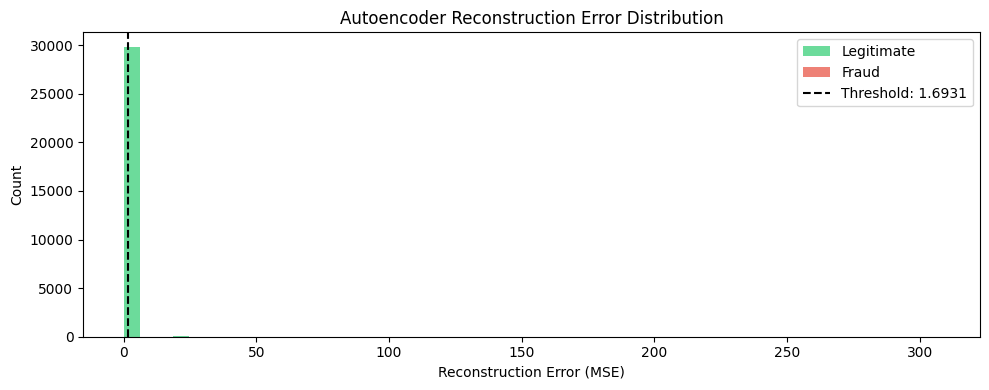

Legitimate transactions in sample: 29957
Fraud transactions in sample:      43


In [11]:
import matplotlib.pyplot as plt

# Use y_sample and mse from the fast autoencoder cell above
# (NOT the full y — that was replaced by sampling)

plt.figure(figsize=(10, 4))
plt.hist(mse[y_sample == 0], bins=50, alpha=0.7,
         color='#2ecc71', label='Legitimate')
plt.hist(mse[y_sample == 1], bins=50, alpha=0.7,
         color='#e74c3c', label='Fraud')
plt.axvline(threshold, color='black',
            linestyle='--', label=f'Threshold: {threshold:.4f}')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Legitimate transactions in sample: {(y_sample==0).sum()}")
print(f"Fraud transactions in sample:      {(y_sample==1).sum()}")

In [12]:
from sklearn.neighbors import LocalOutlierFactor

lof_size = min(10000, len(X_sample))
lof_idx  = np.random.choice(len(X_sample), size=lof_size, replace=False)

X_lof    = X_sample[lof_idx]
y_lof    = np.array(y_sample)[lof_idx]

lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_lof = lof.fit_predict(X_lof)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

print("LOF Results")
print(confusion_matrix(y_lof, y_pred_lof))
print(classification_report(y_lof, y_pred_lof))

LOF Results
[[8995  991]
 [   5    9]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      9986
           1       0.01      0.64      0.02        14

    accuracy                           0.90     10000
   macro avg       0.50      0.77      0.48     10000
weighted avg       1.00      0.90      0.95     10000



In [13]:
# KMeans — use X_sample for speed
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_sample)

distances    = np.min(kmeans.transform(X_sample), axis=1)
threshold_km = np.percentile(distances, 90)
y_pred_km    = (distances > threshold_km).astype(int)

print("K-Means Results")
print(confusion_matrix(y_sample, y_pred_km))
print(classification_report(y_sample, y_pred_km))

K-Means Results
[[26985  2972]
 [   15    28]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     29957
           1       0.01      0.65      0.02        43

    accuracy                           0.90     30000
   macro avg       0.50      0.78      0.48     30000
weighted avg       1.00      0.90      0.95     30000



In [14]:
# Random Forest — use X_sample and y_sample
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.3, random_state=42, stratify=y_sample)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))


[[8987    0]
 [  13    0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8987
           1       0.00      0.00      0.00        13

    accuracy                           1.00      9000
   macro avg       0.50      0.50      0.50      9000
weighted avg       1.00      1.00      1.00      9000

ROC AUC: 0.8346971266187913


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
print("=" * 55)
print("   ANOMALY DETECTION COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Method':<25} {'Type':<15} {'Approach'}")
print("-" * 55)
print(f"{'Autoencoder':<25} {'Unsupervised':<15} Reconstruction error")
print(f"{'LOF':<25} {'Unsupervised':<15} Density based")
print(f"{'K-Means':<25} {'Unsupervised':<15} Distance based")
print(f"{'Random Forest':<25} {'Supervised':<15} Label based")
print("=" * 55)
print("✅ Unsupervised models detect fraud without labels")
print("✅ Supervised model uses labeled fraud data")

   ANOMALY DETECTION COMPARISON SUMMARY
Method                    Type            Approach
-------------------------------------------------------
Autoencoder               Unsupervised    Reconstruction error
LOF                       Unsupervised    Density based
K-Means                   Unsupervised    Distance based
Random Forest             Supervised      Label based
✅ Unsupervised models detect fraud without labels
✅ Supervised model uses labeled fraud data


In [16]:
!pip install networkx -q

import networkx as nx
import matplotlib.pyplot as plt

In [17]:
# ✅ Reload dataset for Graph Analysis section
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv')

print(f"✅ Reloaded {len(df)} transactions for graph analysis")
df.head()

✅ Reloaded 6362620 transactions for graph analysis


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,3409,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,8530,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,2220,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,5150,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,2723,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


In [18]:
# SPEED FIX FOR GRAPH — sample 500 users only
sample_users = np.random.choice(
    df['User_ID'].unique(),
    size=min(500, df['User_ID'].nunique()),
    replace=False
)
df_graph = df[df['User_ID'].isin(sample_users)].copy()

print(f"✅ Graph will use {len(df_graph)} rows | {df_graph['User_ID'].nunique()} users")

✅ Graph will use 318074 rows | 500 users


In [19]:
# Build graph using df_graph (500 users only — fast)
G = nx.Graph()

for user in df_graph['User_ID'].unique():
    G.add_node(user)

for location in df_graph['Location'].dropna().unique():
    users = df_graph[df_graph['Location'] == location]['User_ID'].unique()
    for i in range(len(users)):
        for j in range(i+1, len(users)):
            G.add_edge(users[i], users[j])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 500
Number of edges: 124750


/tmp/ipykernel_2659/254018837.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


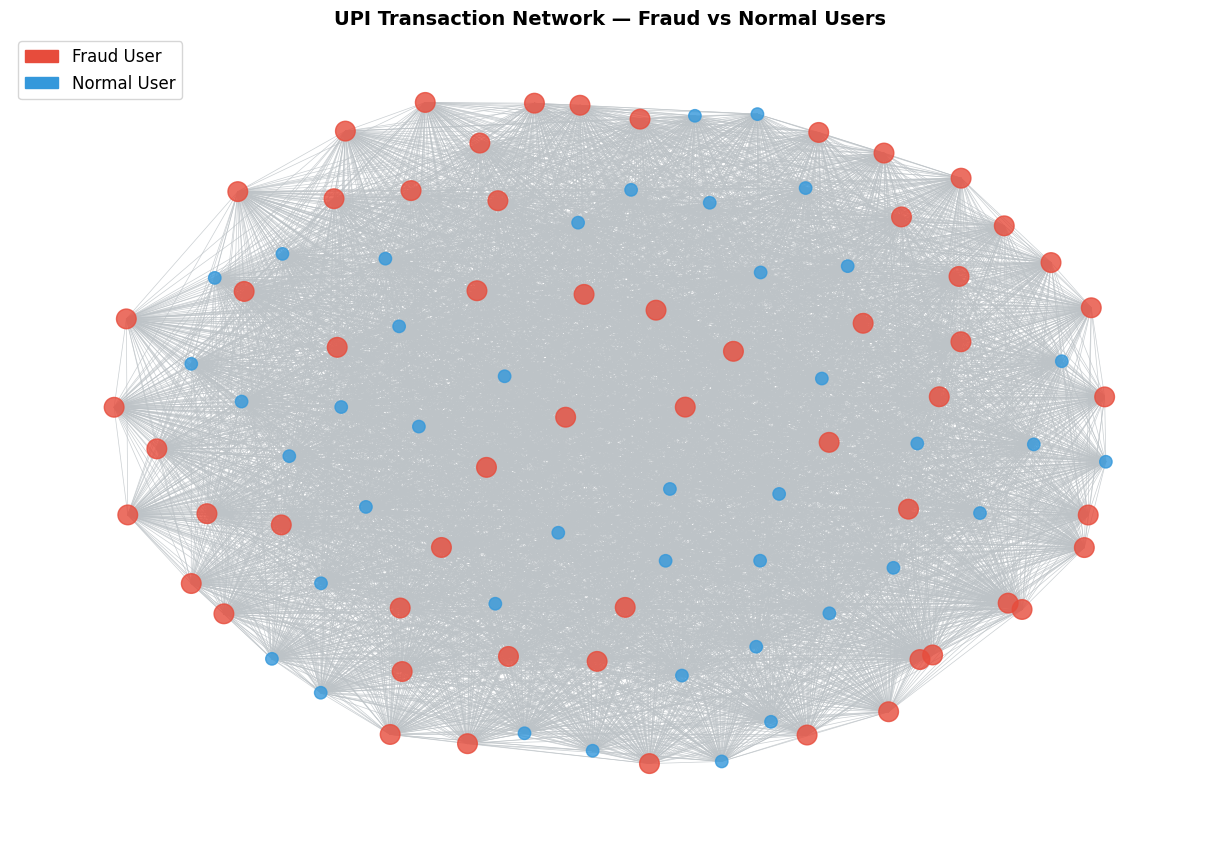

Total nodes shown: 100
Red nodes (fraud): 58
Blue nodes (normal): 42


In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Sample 100 nodes so graph is readable
sample_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(sample_nodes)

# Color fraud users red, normal users blue
fraud_users_set = set(df_graph[df_graph['Fraudulent'] == 1]['User_ID'].unique())
colors = ['#e74c3c' if node in fraud_users_set
          else '#3498db' for node in subgraph.nodes()]

# Size fraud nodes bigger so they stand out
sizes = [200 if node in fraud_users_set
         else 80 for node in subgraph.nodes()]

# Draw the graph
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph,
        pos=pos,
        node_color=colors,
        node_size=sizes,
        with_labels=False,
        edge_color='#bdc3c7',
        width=0.5,
        alpha=0.8)

# Add legend manually
import matplotlib.patches as mpatches
fraud_patch  = mpatches.Patch(color='#e74c3c', label='Fraud User')
normal_patch = mpatches.Patch(color='#3498db', label='Normal User')
plt.legend(handles=[fraud_patch, normal_patch],
           loc='upper left', fontsize=12)

plt.title('UPI Transaction Network — Fraud vs Normal Users',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total nodes shown: {subgraph.number_of_nodes()}")
print(f"Red nodes (fraud): {sum(1 for n in subgraph.nodes() if n in fraud_users_set)}")
print(f"Blue nodes (normal): {sum(1 for n in subgraph.nodes() if n not in fraud_users_set)}")

In [21]:
mule_candidates = df_graph[
    (df_graph['Number_of_Transactions_Last_24H'] > 10) &
    (df_graph['Previous_Fraudulent_Transactions'] > 0)
]['User_ID'].unique()

print(f"Potential Mule-Like Accounts detected: {len(mule_candidates)}")
print("User IDs:", mule_candidates[:10])

Potential Mule-Like Accounts detected: 454
User IDs: [  78 7219 3650 1478 9607 7533 3516 5769 5404 6386]


/tmp/ipykernel_2659/3010740179.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


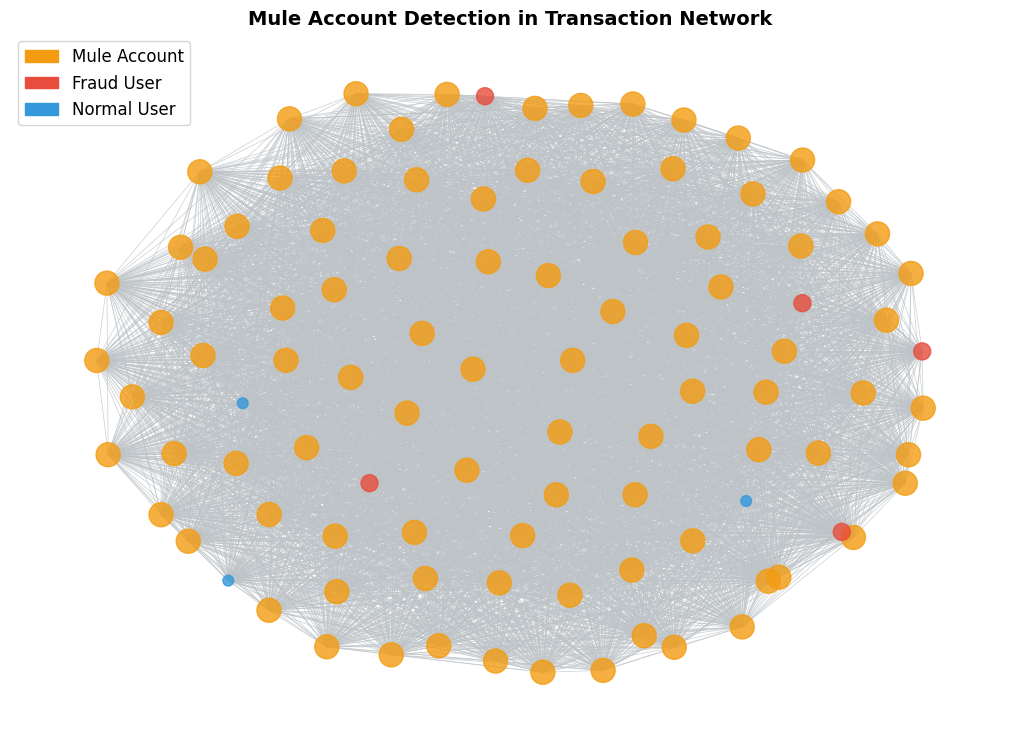

Mule accounts highlighted: 92


In [22]:
plt.figure(figsize=(10, 7))

# Highlight mule accounts in the graph
mule_set = set(mule_candidates)

sample_nodes = list(G.nodes())[:100]
subgraph = G.subgraph(sample_nodes)

# 3 colors — mule = orange, fraud = red, normal = blue
colors = []
for node in subgraph.nodes():
    if node in mule_set:
        colors.append('#f39c12')   # orange = mule
    elif node in fraud_users_set:
        colors.append('#e74c3c')   # red = fraud
    else:
        colors.append('#3498db')   # blue = normal

sizes = [300 if node in mule_set else
         150 if node in fraud_users_set else
         60 for node in subgraph.nodes()]

pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph,
        pos=pos,
        node_color=colors,
        node_size=sizes,
        with_labels=False,
        edge_color='#bdc3c7',
        width=0.5,
        alpha=0.8)

# Legend
mule_patch   = mpatches.Patch(color='#f39c12', label='Mule Account')
fraud_patch  = mpatches.Patch(color='#e74c3c', label='Fraud User')
normal_patch = mpatches.Patch(color='#3498db', label='Normal User')
plt.legend(handles=[mule_patch, fraud_patch, normal_patch],
           loc='upper left', fontsize=12)

plt.title('Mule Account Detection in Transaction Network',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mule accounts highlighted: {sum(1 for n in subgraph.nodes() if n in mule_set)}")

In [23]:
fraud_users     = df_graph[df_graph['Fraudulent'] == 1]['User_ID'].unique()
fraud_subgraph  = G.subgraph(fraud_users)
print("Fraud Cluster Nodes:", list(fraud_subgraph.nodes())[:10])

Fraud Cluster Nodes: [np.int64(2220), np.int64(4775), np.int64(5991), np.int64(8301), np.int64(214), np.int64(7961), np.int64(3516), np.int64(3321), np.int64(1889), np.int64(6781)]


In [24]:
degree_centrality = nx.degree_centrality(G)

top_users = sorted(degree_centrality.items(),
                   key=lambda x: x[1],
                   reverse=True)

print("Top 5 Most Connected Users:")
print(top_users[:5])

Top 5 Most Connected Users:
[(np.int64(2220), 0.9999999999999999), (np.int64(4775), 0.9999999999999999), (np.int64(5991), 0.9999999999999999), (np.int64(8301), 0.9999999999999999), (np.int64(3650), 0.9999999999999999)]


/tmp/ipykernel_2659/3522964993.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


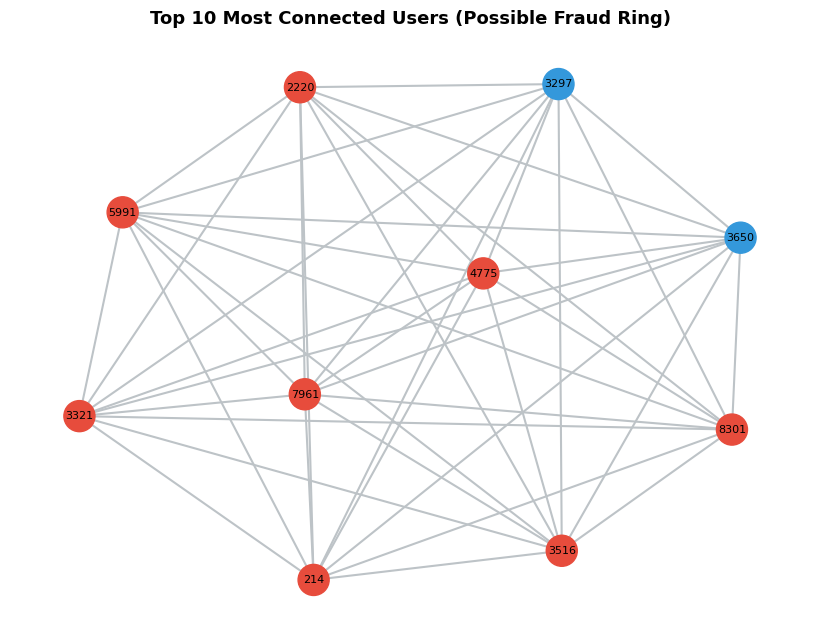

In [25]:
# Visualize top 10 most connected users
top_10_users = [user for user, score in top_users[:10]]
subgraph_top = G.subgraph(top_10_users)

plt.figure(figsize=(8, 6))

colors_top = ['#e74c3c' if node in fraud_users_set
              else '#3498db' for node in subgraph_top.nodes()]

pos_top = nx.spring_layout(subgraph_top, seed=42)
nx.draw(subgraph_top,
        pos=pos_top,
        node_color=colors_top,
        node_size=500,
        with_labels=True,
        font_size=8,
        edge_color='#bdc3c7',
        width=1.5)

plt.title('Top 10 Most Connected Users (Possible Fraud Ring)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
from networkx.algorithms import community

if G.number_of_nodes() <= 500:
    communities = community.greedy_modularity_communities(G)
    print(f"Total communities found: {len(communities)}")
    for i, comm in enumerate(list(communities)[:5]):
        print(f"Community {i+1}: {list(comm)[:5]}...")
else:
    print("Graph too large — reduce sample size")

Total communities found: 1
Community 1: [np.int64(7173), np.int64(5127), np.int64(2056), np.int64(7177), np.int64(5131)]...


In [27]:
# Install (run once in Colab)
!pip install shap

# Imports
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [29]:
X_test_df = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=X.columns
)

In [30]:
model = rf  # your trained model

explainer = shap.Explainer(model, X_test_df)
shap_values = explainer(X_test_df)

 99%|===================| 17876/18000 [00:30<00:00]       

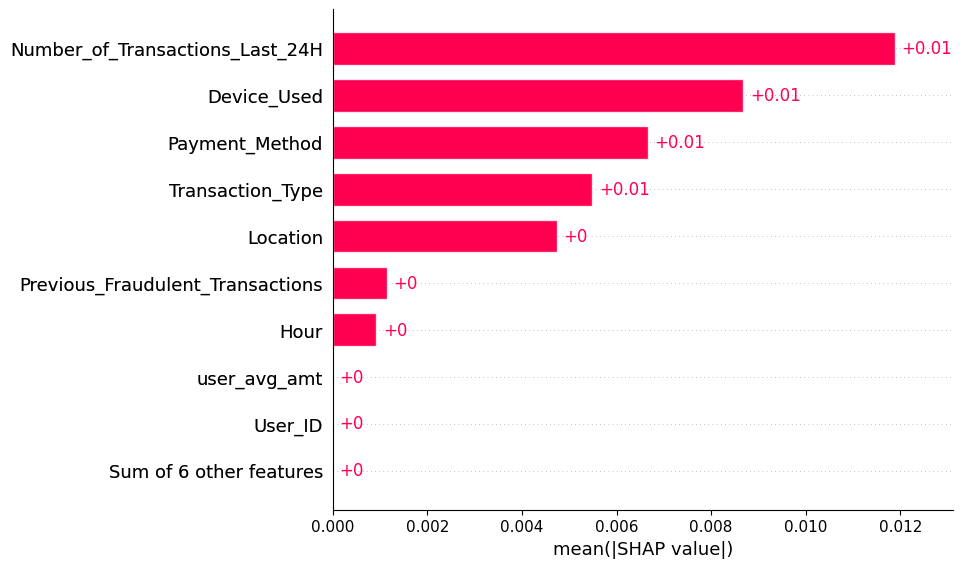

In [31]:
shap.plots.bar(shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[1],
    data=shap_values.data,
    feature_names=shap_values.feature_names
))

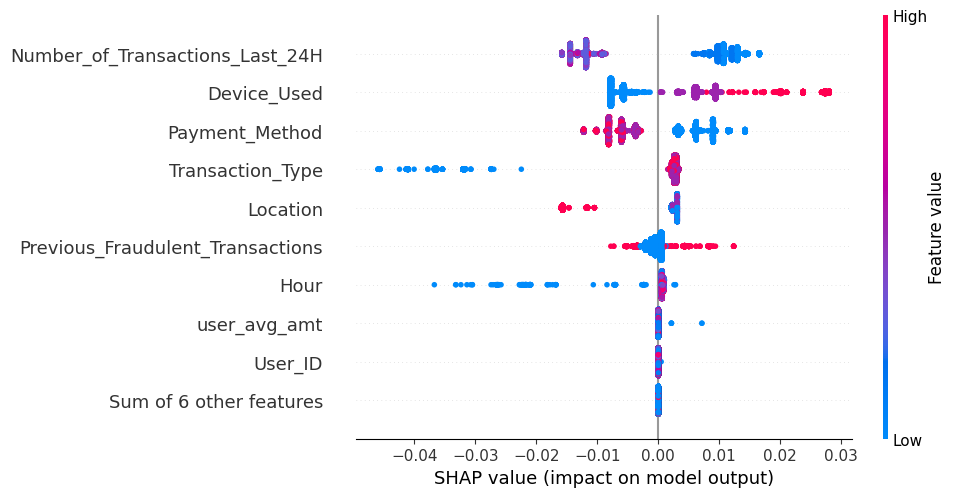

In [32]:
shap.plots.beeswarm(shap.Explanation(
    values=shap_values.values[:, :, 1],
    base_values=shap_values.base_values[1],
    data=shap_values.data,
    feature_names=shap_values.feature_names
))

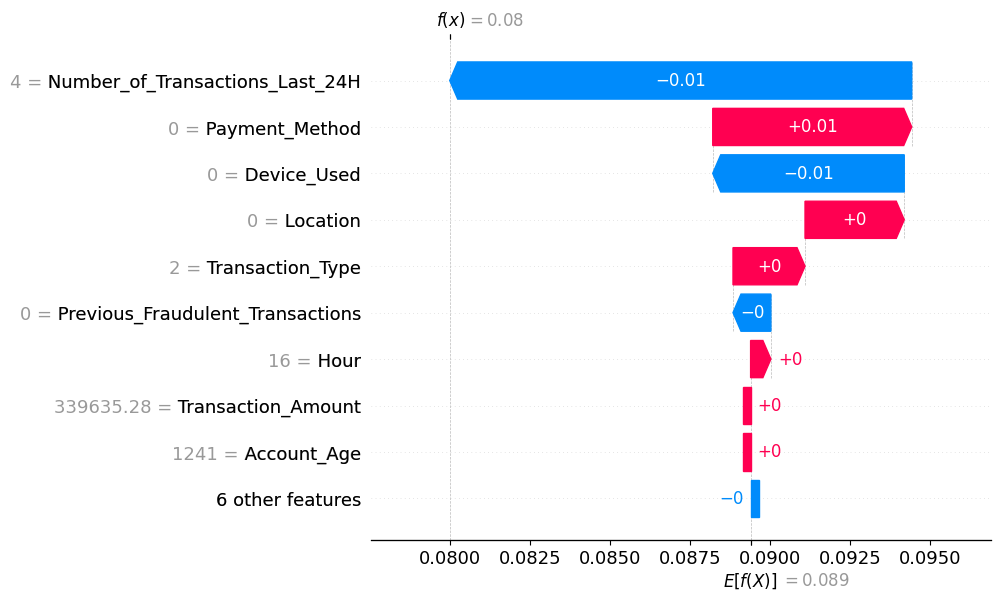

In [33]:
index = 0
shap.plots.waterfall(shap_values[index, :, 1])

In [34]:
index = 0

print("Transaction Explanation:\n")

for feature, value, impact_array in zip(
    X_test_df.columns,
    X_test_df.iloc[index],
    shap_values[index].values
):
    impact = impact_array[1] # Get impact for the fraudulent class (class 1)
    print(f"{feature} = {value} → Impact: {impact:.4f}")

Transaction Explanation:

User_ID = 7777.0 → Impact: 0.0000
Transaction_Amount = 339635.28 → Impact: 0.0000
Transaction_Type = 2.0 → Impact: 0.0022
Device_Used = 0.0 → Impact: -0.0060
Location = 0.0 → Impact: 0.0031
Previous_Fraudulent_Transactions = 0.0 → Impact: -0.0012
Account_Age = 1241.0 → Impact: 0.0000
Number_of_Transactions_Last_24H = 4.0 → Impact: -0.0144
Payment_Method = 0.0 → Impact: 0.0062
Hour = 16.0 → Impact: 0.0006
txn_count_user = 1.0 → Impact: 0.0000
user_avg_amt = 339635.28 → Impact: 0.0000
amt_deviation = 0.0 → Impact: 0.0000
night_txn = 1.3877787807814457e-17 → Impact: 0.0000
device_change = 0.0 → Impact: 0.0000


In [35]:
explanation = pd.DataFrame({
    "Feature": X_test_df.columns,
    "Value": X_test_df.iloc[index],
    "Impact": shap_values[index].values[:, 1] # Select impact for class 1 (fraudulent)
})

explanation["AbsImpact"] = np.abs(explanation["Impact"])

explanation = explanation.sort_values(by="AbsImpact", ascending=False)

print(explanation.head(5))

                                                         Feature  Value  \
Number_of_Transactions_Last_24H  Number_of_Transactions_Last_24H    4.0   
Payment_Method                                    Payment_Method    0.0   
Device_Used                                          Device_Used    0.0   
Location                                                Location    0.0   
Transaction_Type                                Transaction_Type    2.0   

                                   Impact  AbsImpact  
Number_of_Transactions_Last_24H -0.014433   0.014433  
Payment_Method                   0.006217   0.006217  
Device_Used                     -0.005983   0.005983  
Location                         0.003100   0.003100  
Transaction_Type                 0.002250   0.002250  


In [36]:
# ====================================================
# HYBRID ENSEMBLE — Rajeshwari's Autoencoder + Brinda's XGBoost
# ====================================================

import joblib
import numpy as np
from sklearn.metrics import classification_report, f1_score, roc_auc_score

drive_path = '/content/drive/MyDrive/Colab Notebooks/'

# Load Brinda's trained XGBoost model
xgb_model    = joblib.load(drive_path + 'final_fraud_model.pkl')
xgb_scaler   = joblib.load(drive_path + 'scaler.pkl')
xgb_features = joblib.load(drive_path + 'feature_list.pkl')

print("✅ Loaded Brinda's XGBoost model")
print(f"XGBoost features: {xgb_features}")

# Prepare data using only XGBoost's 12 features
# Use same sample size as autoencoder for fair comparison
X_xgb_sample = df.iloc[all_idx][xgb_features].fillna(df[xgb_features].median())
y_xgb        = df['Fraudulent'].iloc[all_idx]
X_xgb_scaled = xgb_scaler.transform(X_xgb_sample)

# XGBoost fraud probabilities (supervised)
xgb_probs = xgb_model.predict_proba(X_xgb_scaled)[:, 1]

# Autoencoder anomaly scores (unsupervised, already trained in Cell 9)
reconstructions = autoencoder.predict(X_sample, verbose=0)
mse_scores      = np.mean(np.power(X_sample - reconstructions, 2), axis=1)

# Normalize MSE to 0–1 so it matches probability scale
mse_norm = (mse_scores - mse_scores.min()) / (mse_scores.max() - mse_scores.min())

# Combine: XGBoost 70% + Autoencoder 30%
hybrid_score = 0.70 * xgb_probs + 0.30 * mse_norm

# Find best threshold
best_f1, best_thresh = 0, 0.5
for t in np.arange(0.05, 0.95, 0.01):
    preds = (hybrid_score >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_xgb, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, float(t)

hybrid_preds = (hybrid_score >= best_thresh).astype(int)

print("\n" + "="*55)
print("   HYBRID ENSEMBLE RESULTS (XGBoost + Autoencoder)")
print("="*55)
print(f"Best threshold: {best_thresh:.2f}")
print(classification_report(y_xgb, hybrid_preds))
print(f"ROC-AUC: {roc_auc_score(y_xgb, hybrid_score):.4f}")

# Final comparison
print("="*55)
print("   FINAL COMPARISON")
print("="*55)
print(f"{'Method':<30} {'F1':>8} {'ROC-AUC':>10}")
print("-"*50)

xgb_preds_alone = (xgb_probs >= 0.5).astype(int)
print(f"{'XGBoost (Supervised)':<30} {f1_score(y_xgb, xgb_preds_alone):>8.4f} {roc_auc_score(y_xgb, xgb_probs):>10.4f}")

ae_thresh = np.percentile(mse_norm, 95)
ae_preds  = (mse_norm > ae_thresh).astype(int)
print(f"{'Autoencoder (Unsupervised)':<30} {f1_score(y_xgb, ae_preds):>8.4f} {roc_auc_score(y_xgb, mse_norm):>10.4f}")

print(f"{'Hybrid (XGB + Autoencoder)':<30} {best_f1:>8.4f} {roc_auc_score(y_xgb, hybrid_score):>10.4f}")
print("="*50)
print("✅ Hybrid ensemble complete")

# Save
joblib.dump(best_thresh, drive_path + 'hybrid_threshold.pkl')
autoencoder.save(drive_path + 'autoencoder_model.keras')
print("✅ hybrid_threshold.pkl saved")
print("✅ autoencoder_model.keras saved")

✅ Loaded Brinda's XGBoost model
XGBoost features: ['User_ID', 'Transaction_Amount', 'Transaction_Type', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Hour', 'night_txn', 'device_change']

   HYBRID ENSEMBLE RESULTS (XGBoost + Autoencoder)
Best threshold: 0.66
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29957
           1       0.68      0.30      0.42        43

    accuracy                           1.00     30000
   macro avg       0.84      0.65      0.71     30000
weighted avg       1.00      1.00      1.00     30000

ROC-AUC: 0.9673
   FINAL COMPARISON
Method                               F1    ROC-AUC
--------------------------------------------------
XGBoost (Supervised)             0.1812     0.9674
Autoencoder (Unsupervised)       0.0285     0.8426
Hybrid (XGB + Autoencoder)       0.4194     0.9673
✅ Hybrid ensemble complete
✅ hybrid_